In [1]:
%matplotlib widget
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt

import pandas as pd

import gymnasium as gym
import csv
import time
from gym.wrappers import RecordVideo

from tqdm import tqdm 

import pickle as pkl
import os

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [2]:
os.makedirs('./data', exist_ok=True)

In [3]:
class ConditionalDiffusionNet(nn.Module):
    def __init__(self,data_dim,cond_dim):
        super(ConditionalDiffusionNet,self).__init__()
        n_unit = 256

        self.l1 = nn.Linear(data_dim, n_unit)
        self.l2 = nn.Linear(n_unit, n_unit)

        self.l1_beta = nn.Linear(1, n_unit)
        self.l2_beta = nn.Linear(n_unit, n_unit)

        self.l1_cond = nn.Linear(cond_dim, n_unit)
        self.l2_cond = nn.Linear(n_unit, n_unit)

        self.l3 = nn.Linear(n_unit,n_unit)
        self.l4 = nn.Linear(n_unit,data_dim)
    
    def forward(self,x,c,t):
        xx = self.l1(x)
        xx = F.relu(xx)
        xx = self.l2(xx)
        xx = F.relu(xx)

        cc = self.l1_cond(c)
        cc = F.relu(cc)
        cc = self.l2_cond(cc)
        cc = F.relu(cc)

        bb = self.l1_beta(t)
        bb = F.relu(bb)
        bb = self.l2_beta(bb)
        bb = F.relu(bb)

        xx = self.l3(xx+bb+cc)
        xx = F.relu(xx)
        xx = self.l4(xx)

        return xx

In [4]:
class ConditionalDenoisingDiffusionProbabilisticModel():
    def __init__(self, X, cond, beta, device, batch_size=32):
        self.device = device

        self.X = X
        self.x_dim = self.X.shape[1]
        self.C = cond
        self.c_dim = self.C.shape[1]
        self.beta = beta
        self.n_beta = self.beta.shape[0]

        alpha = 1 - self.beta
        self.alpha = torch.tensor([[torch.prod(alpha[:i+1])] for i in range(self.n_beta)]).float()

        self.batch_size = batch_size

        self.model = ConditionalDiffusionNet(self.X.shape[1], self.C.shape[1]).to(self.device)

        train_dataset = torch.utils.data.TensorDataset(self.X, self.C)
        self.train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)

        self.optimizer = optim.Adam(self.model.parameters(), lr=1e-3)



    def learning(self, n_epoch=10):
        self.model.train()

        for e in range(n_epoch):
            for (x_batch, c_batch) in self.train_loader:
                loss_hist = []

                x_batch = x_batch
                c_batch = c_batch
                
                self.optimizer.zero_grad()

                t = torch.randint(low=0, high=self.n_beta, size=(x_batch.shape[0],))
                noise = torch.randn(x_batch.shape[0], self.x_dim)


                x_t = torch.sqrt(self.alpha[t]) * x_batch + torch.sqrt(1-self.alpha[t]) * noise

                noise_pred = self.model(x_t.to(self.device),
                                        c_batch.to(self.device),
                                        t[:,None].float().to(self.device))


                # import ipdb; ipdb.set_trace()
                loss = ((noise_pred - noise.to(device))**2).sum()
                loss_hist.append(loss.detach().cpu().numpy()/x_batch.shape[0])

                loss.backward()

                self.optimizer.step()

            print('epoch: {}, loss: {}'.format(e, np.array(loss_hist).mean()))

        self.model.eval()



    def sampling(self, c, n=100):
        x_sample = torch.randn(n, self.x_dim)
        c_sample = c.repeat(n, 1)

        for t in range(self.n_beta)[::-1]:
            noise = torch.randn(n, self.x_dim)
            if t==0: noise= torch.zeros(n, self.x_dim)

            sigma = torch.sqrt(self.beta[t]*(1-self.alpha[t-1])/(1-self.alpha[t]))

            noise_pred = self.model(x_sample.to(self.device),
                                    c_sample.to(self.device),
                                    torch.tensor([[t]]).float().to(self.device)).detach().cpu()

            # import ipdb;ipdb.set_trace()
            x_sample = (x_sample - self.beta[t]*noise_pred/torch.sqrt(1-self.alpha[t])) / torch.sqrt(1-self.beta[t]) + sigma * noise


        return x_sample

### Load From learnt model weight, just do the sampling for pcolor grid

this code process one pkl weights per time, now we need some kind of automation

In [ ]:
# #get action from ddpm sampling
# def get_ddpm_action(observation, policy_ddpm):
#     # input tensor
#     action = policy_ddpm.sampling(torch.tensor(observation).float(), n=1)
#     return action[0].item()  # get scalar

# # generate state grid
# pos_range = np.linspace(-1.2, 0.6, 100)  # Position
# vel_range = np.linspace(-0.07, 0.07, 100)  # Velocity

# # create grid
# X, Y = np.meshgrid(pos_range, vel_range)

# # 初始化动作存储矩阵
# actions = np.zeros(X.shape)

# # 加载DDPM模型
# with open('./data/learned_policy_fixed_400.pkl', 'rb') as f:
#     policy_ddpm = pkl.load(f)

# # calculate action from each grid
# for i in tqdm(range(X.shape[0]), desc="Calculating actions"):
#     for j in range(X.shape[1]):
#         state = np.array([X[i, j], Y[i, j]])
#         actions[i, j] = get_ddpm_action(state, policy_ddpm)

# # 使用 pcolor 绘制动作
# plt.figure(figsize=(10, 6))
# cmap = mcolors.ListedColormap(['red', 'blue'])  # 自定义颜色映射
# bounds = [-1.5, 0, 1.5]  # 动作的边界
# norm = mcolors.BoundaryNorm(bounds, cmap.N)

# # 绘制 pcolor 图
# plt.pcolor(X, Y, actions, cmap=cmap, shading='auto', norm=norm)
# plt.colorbar(ticks=[-1, 1], label='Action')
# plt.xlabel('Position')
# plt.ylabel('Velocity')
# plt.title('DDPM Policy Action Map (pcolor)')
# plt.axhline(0, color='black', linewidth=0.8, linestyle='--')  # 添加水平线
# plt.axvline(0, color='black', linewidth=0.8, linestyle='--')  # 添加垂直线
# plt.xlim(-1.2, 0.6)
# plt.ylim(-0.07, 0.07)
# plt.grid(False)  # 不显示网格
# plt.show()

reads multiple pkl weights and do 

Processing fixed_policy_data_10.pkl...


Calculating actions for fixed_policy_data_10.pkl: 100%|██████████| 100/100 [28:51<00:00, 17.32s/it]


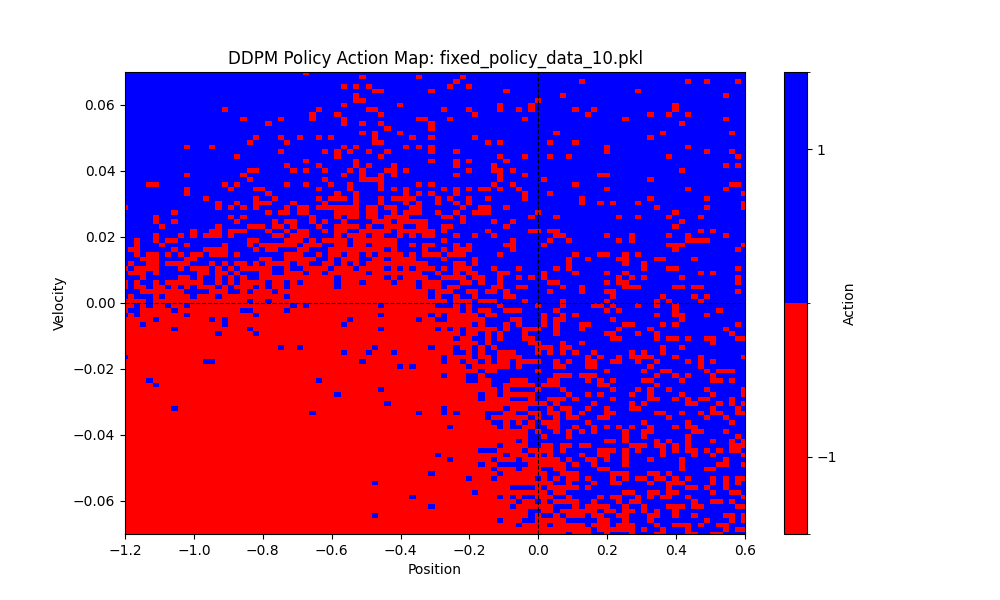

Processing fixed_policy_data_100.pkl...


Calculating actions for fixed_policy_data_100.pkl: 100%|██████████| 100/100 [27:58<00:00, 16.79s/it]


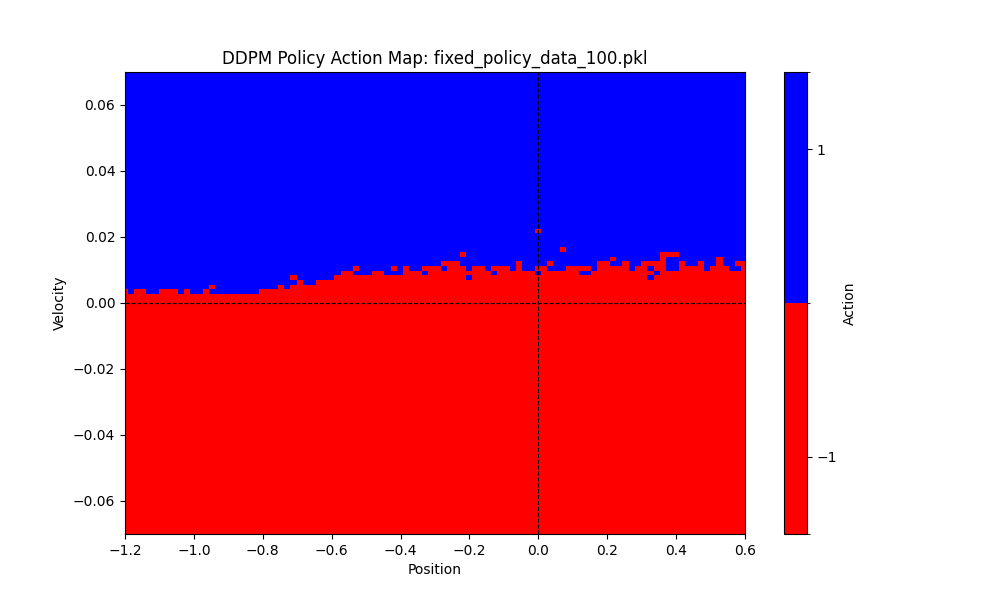

Processing fixed_policy_data_2.pkl...


Calculating actions for fixed_policy_data_2.pkl: 100%|██████████| 100/100 [27:57<00:00, 16.77s/it]


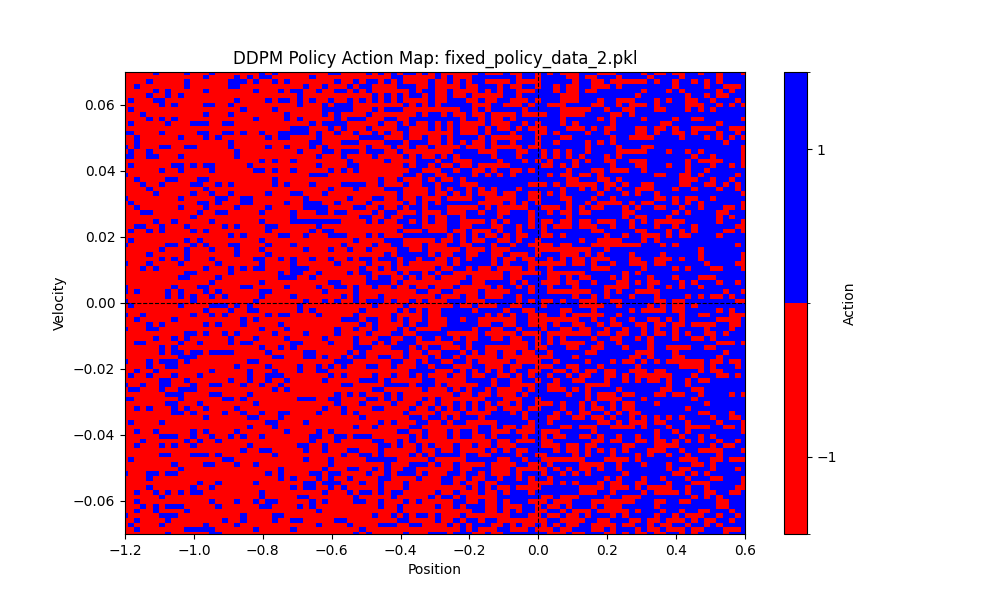

Processing fixed_policy_data_200.pkl...


Calculating actions for fixed_policy_data_200.pkl: 100%|██████████| 100/100 [27:41<00:00, 16.62s/it]


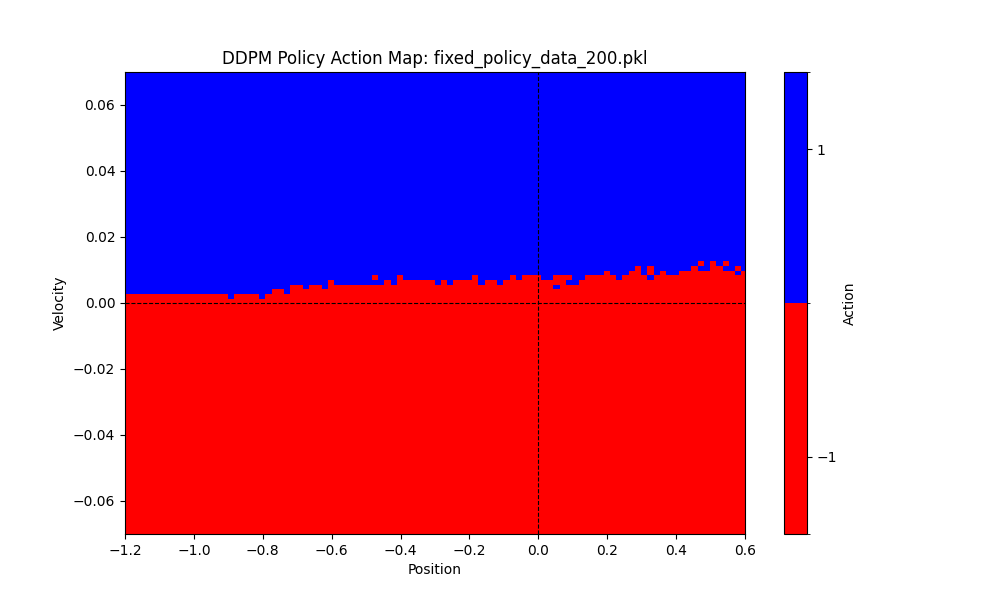

Processing fixed_policy_data_25.pkl...


Calculating actions for fixed_policy_data_25.pkl: 100%|██████████| 100/100 [27:27<00:00, 16.48s/it]


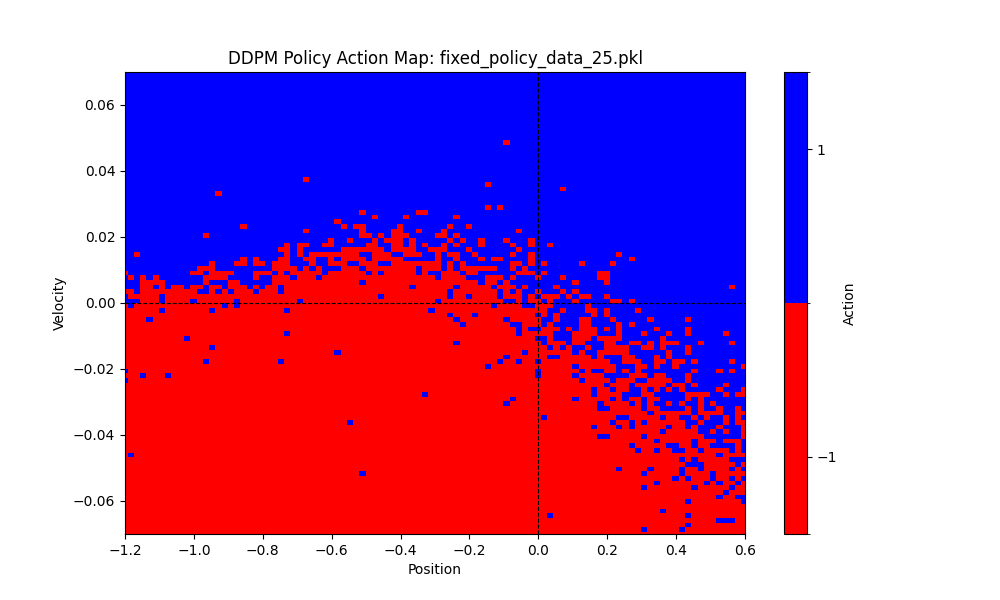

Processing fixed_policy_data_300.pkl...


Calculating actions for fixed_policy_data_300.pkl: 100%|██████████| 100/100 [27:36<00:00, 16.56s/it]


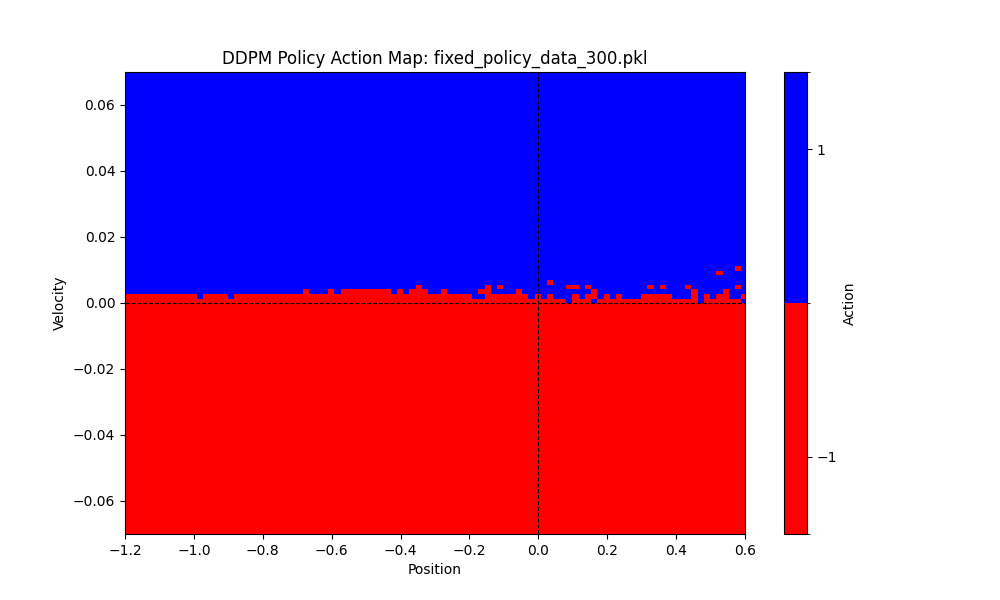

Processing fixed_policy_data_400.pkl...


Calculating actions for fixed_policy_data_400.pkl: 100%|██████████| 100/100 [27:19<00:00, 16.39s/it]


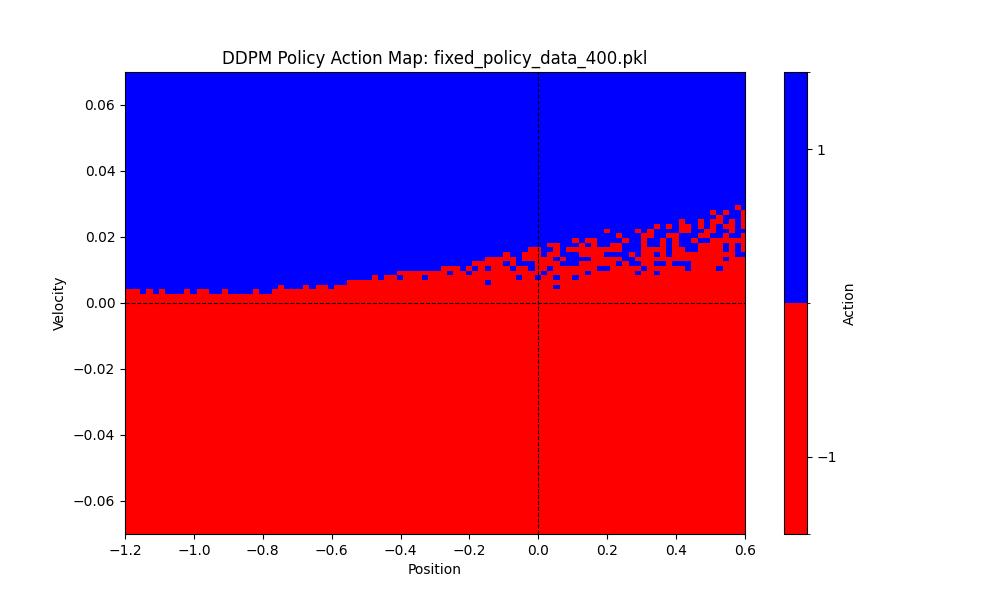

Processing fixed_policy_data_50.pkl...


Calculating actions for fixed_policy_data_50.pkl: 100%|██████████| 100/100 [27:32<00:00, 16.53s/it]


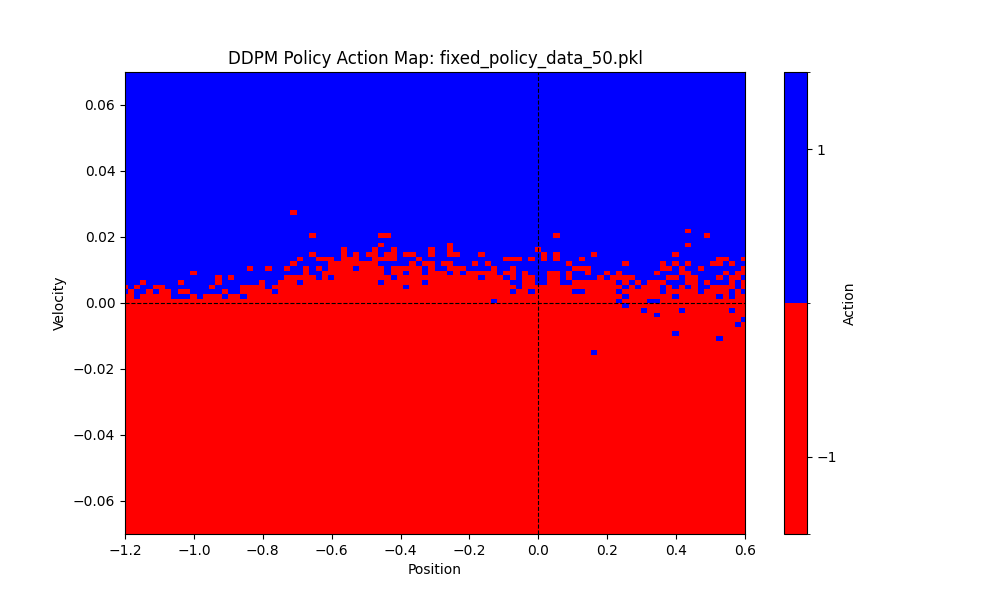

Processing fixed_policy_data_500.pkl...


Calculating actions for fixed_policy_data_500.pkl: 100%|██████████| 100/100 [27:34<00:00, 16.54s/it]


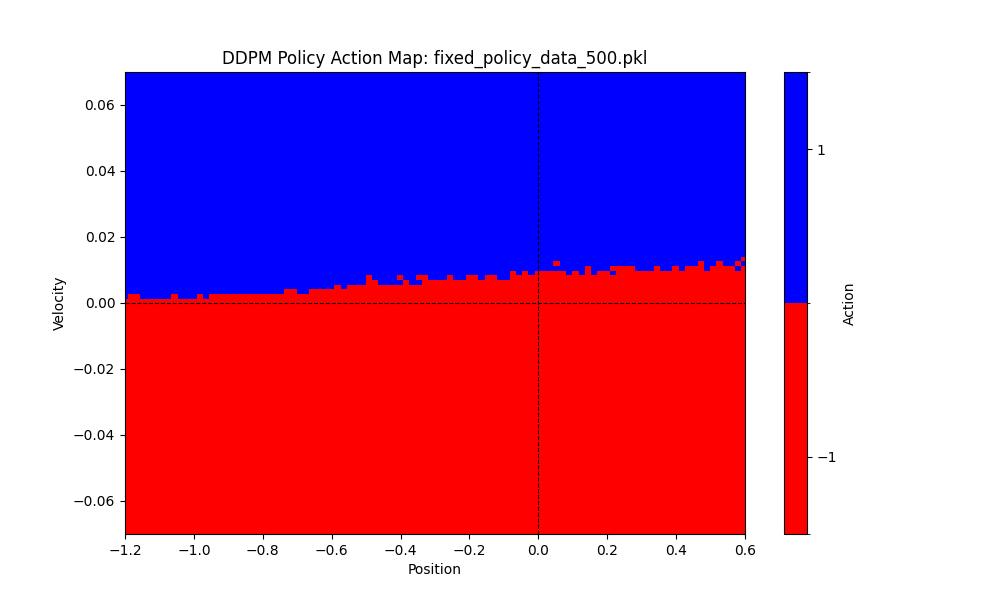

Processing manual_policy_100_LR.pkl...


Calculating actions for manual_policy_100_LR.pkl: 100%|██████████| 100/100 [27:37<00:00, 16.57s/it]


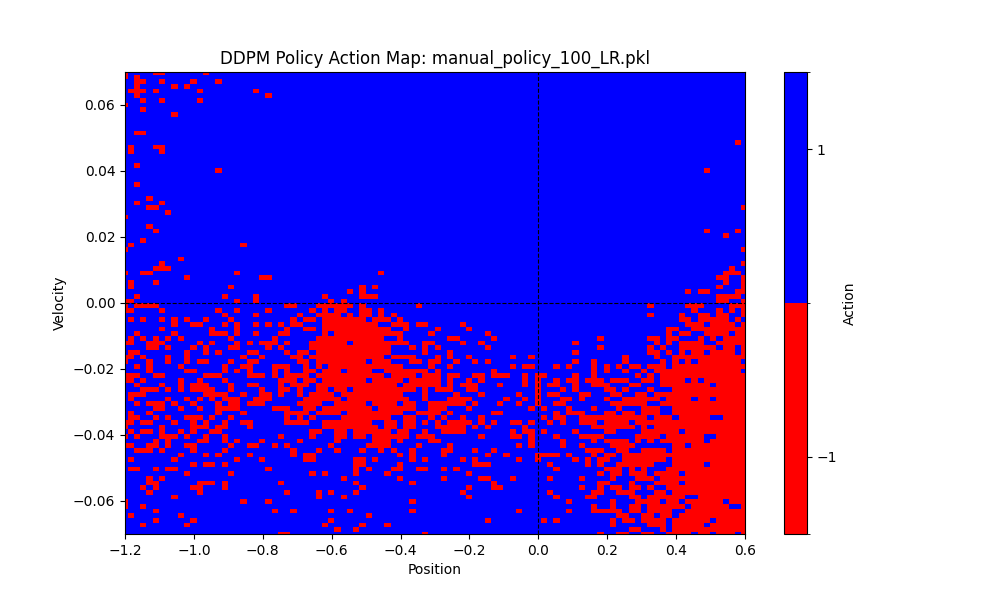

Processing manual_policy_100_LR_RLR.pkl...


Calculating actions for manual_policy_100_LR_RLR.pkl: 100%|██████████| 100/100 [27:39<00:00, 16.60s/it]


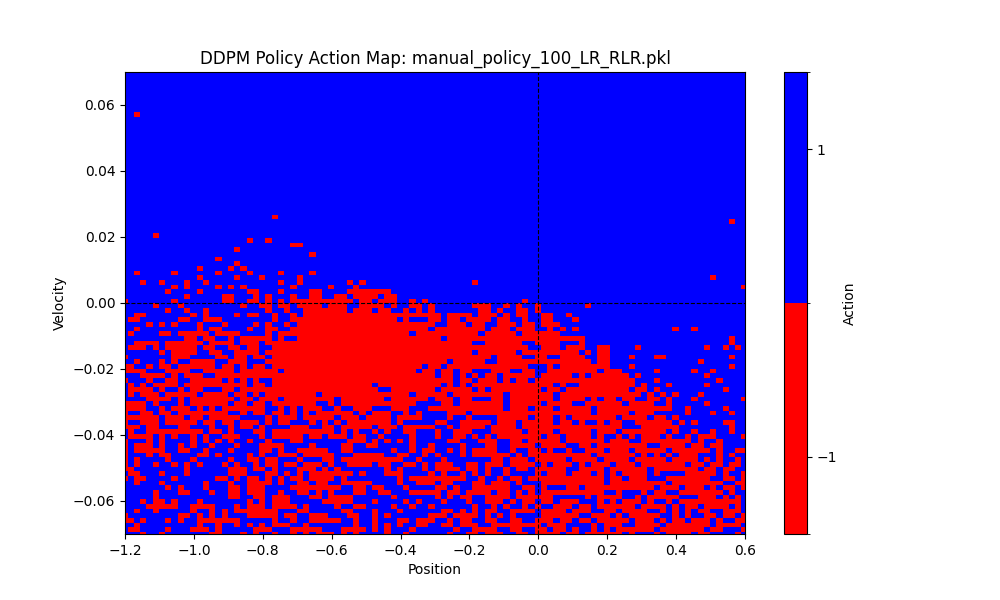

Processing manual_policy_100_RLR.pkl...


Calculating actions for manual_policy_100_RLR.pkl: 100%|██████████| 100/100 [27:37<00:00, 16.57s/it]


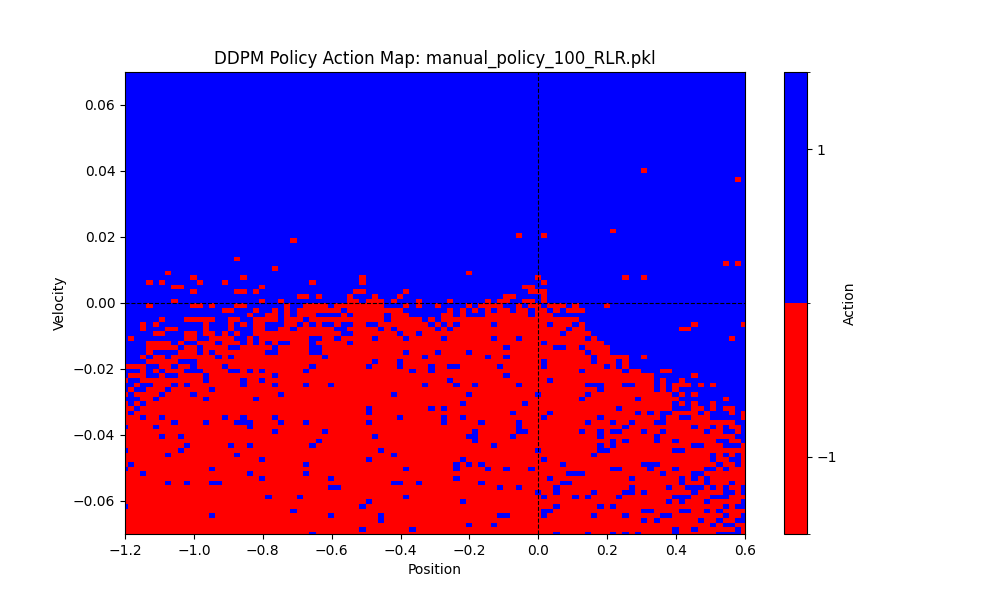

Processing manual_policy_10_LR.pkl...


Calculating actions for manual_policy_10_LR.pkl: 100%|██████████| 100/100 [27:25<00:00, 16.45s/it]


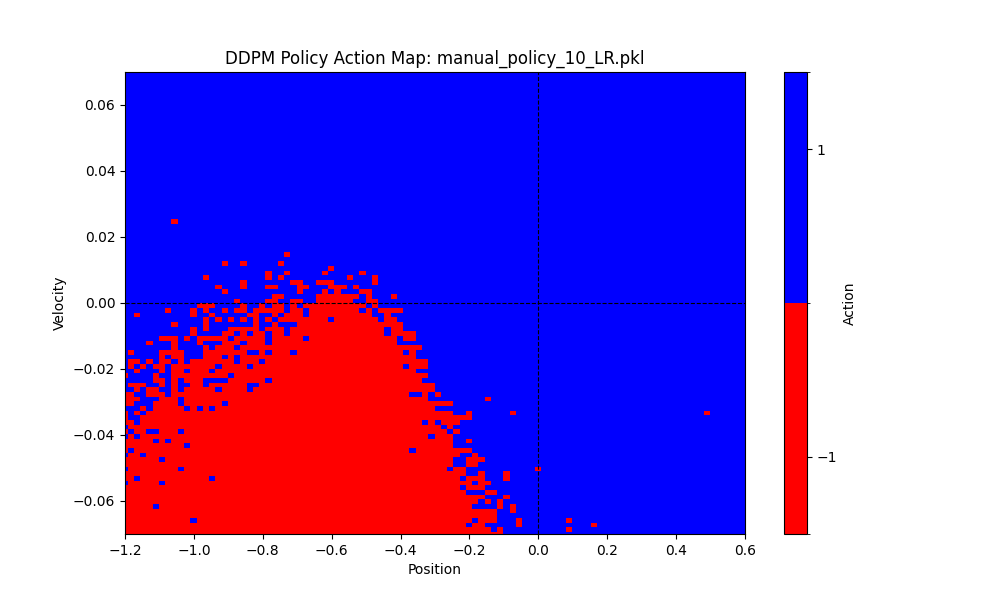

Processing manual_policy_10_LR_RLR.pkl...


Calculating actions for manual_policy_10_LR_RLR.pkl: 100%|██████████| 100/100 [27:31<00:00, 16.51s/it]


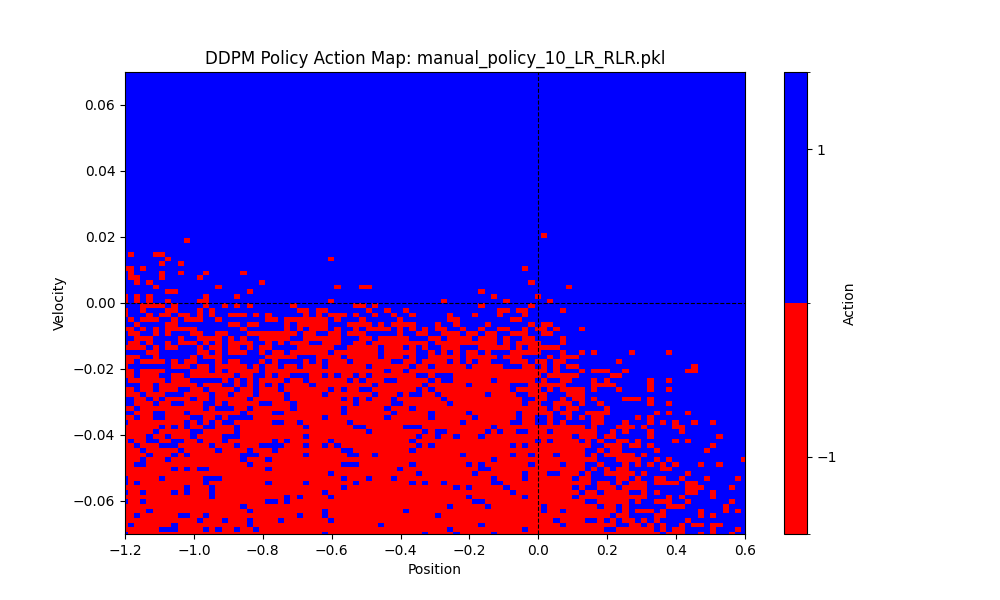

Processing manual_policy_10_RLR.pkl...


Calculating actions for manual_policy_10_RLR.pkl: 100%|██████████| 100/100 [27:33<00:00, 16.53s/it]


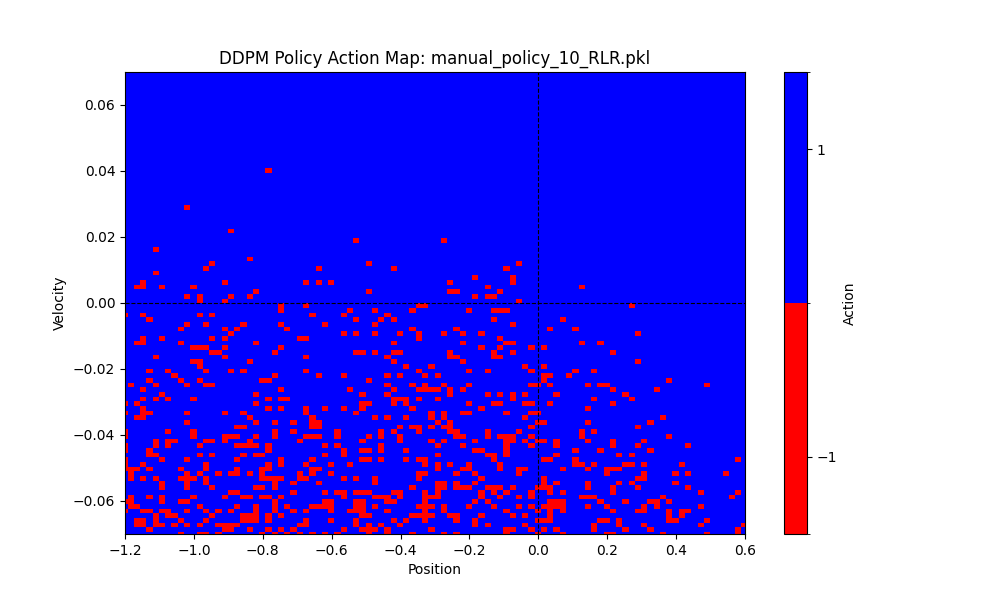

Processing manual_policy_2_LR.pkl...


Calculating actions for manual_policy_2_LR.pkl: 100%|██████████| 100/100 [27:43<00:00, 16.63s/it]


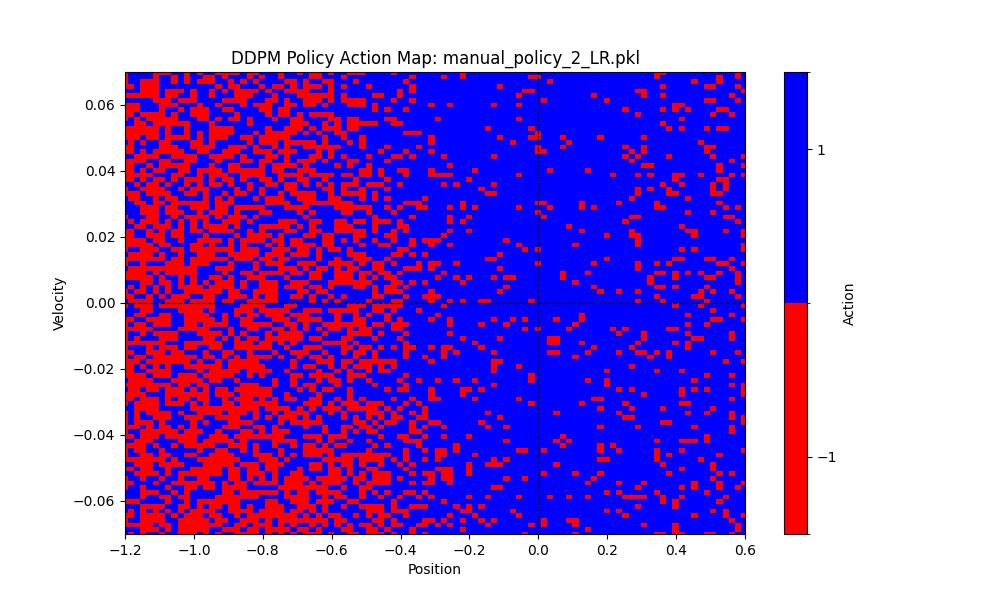

Processing manual_policy_2_LR_RLR.pkl...


Calculating actions for manual_policy_2_LR_RLR.pkl: 100%|██████████| 100/100 [27:42<00:00, 16.62s/it]


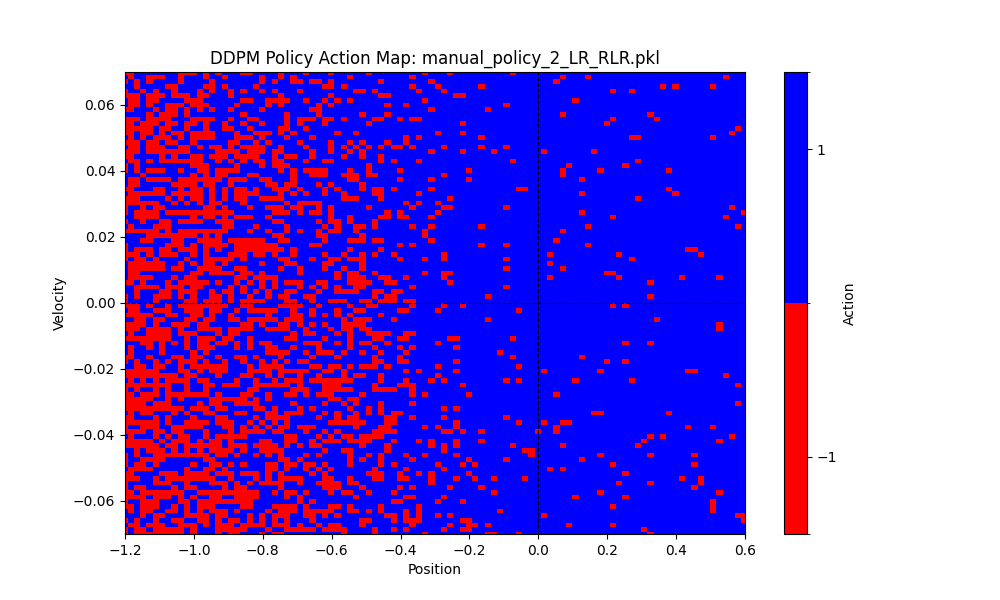

Processing manual_policy_2_RLR.pkl...


Calculating actions for manual_policy_2_RLR.pkl: 100%|██████████| 100/100 [28:05<00:00, 16.85s/it]


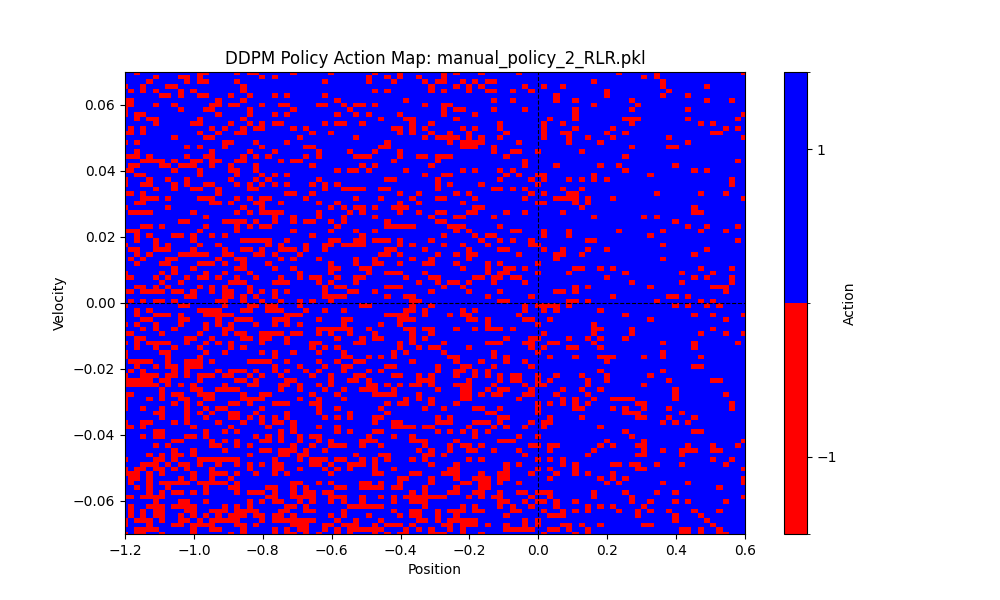

Processing manual_policy_3_LR.pkl...


Calculating actions for manual_policy_3_LR.pkl: 100%|██████████| 100/100 [27:55<00:00, 16.75s/it]


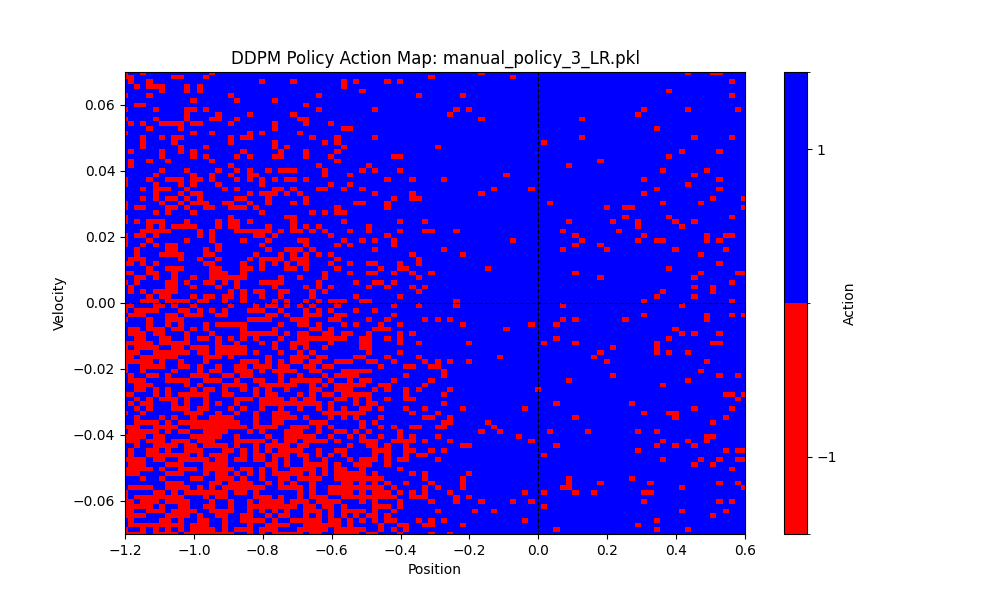

Processing manual_policy_3_RLR.pkl...


Calculating actions for manual_policy_3_RLR.pkl: 100%|██████████| 100/100 [27:51<00:00, 16.71s/it]


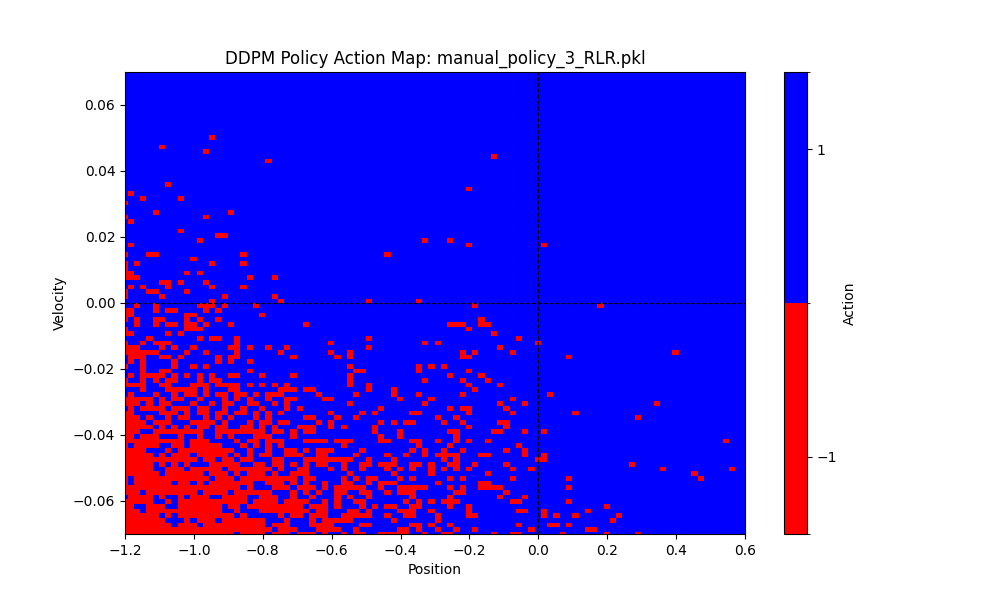

Processing manual_policy_4_LR.pkl...


Calculating actions for manual_policy_4_LR.pkl: 100%|██████████| 100/100 [27:59<00:00, 16.80s/it]


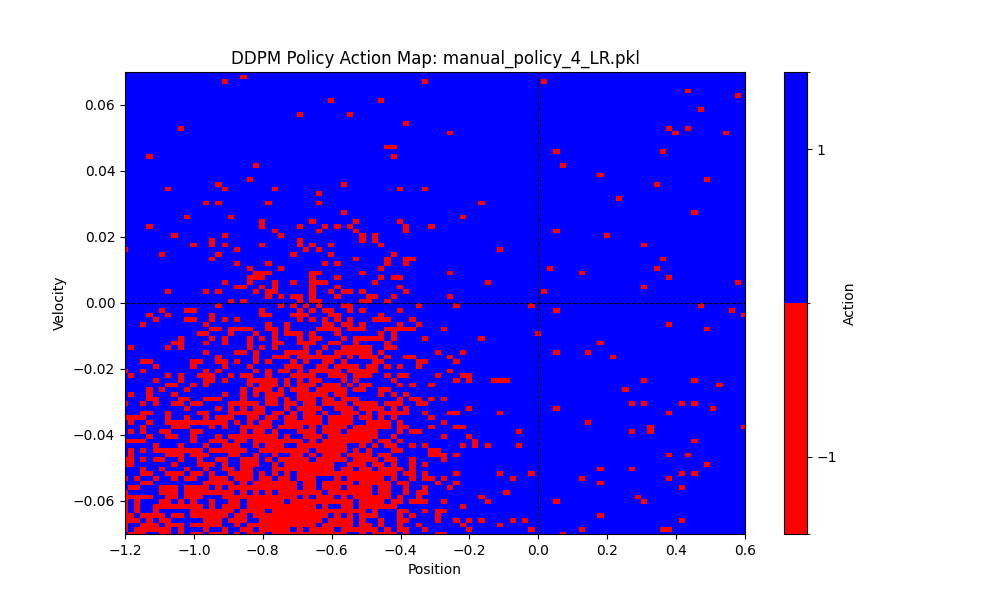

Processing manual_policy_4_LR_RLR.pkl...


Calculating actions for manual_policy_4_LR_RLR.pkl: 100%|██████████| 100/100 [28:14<00:00, 16.94s/it]


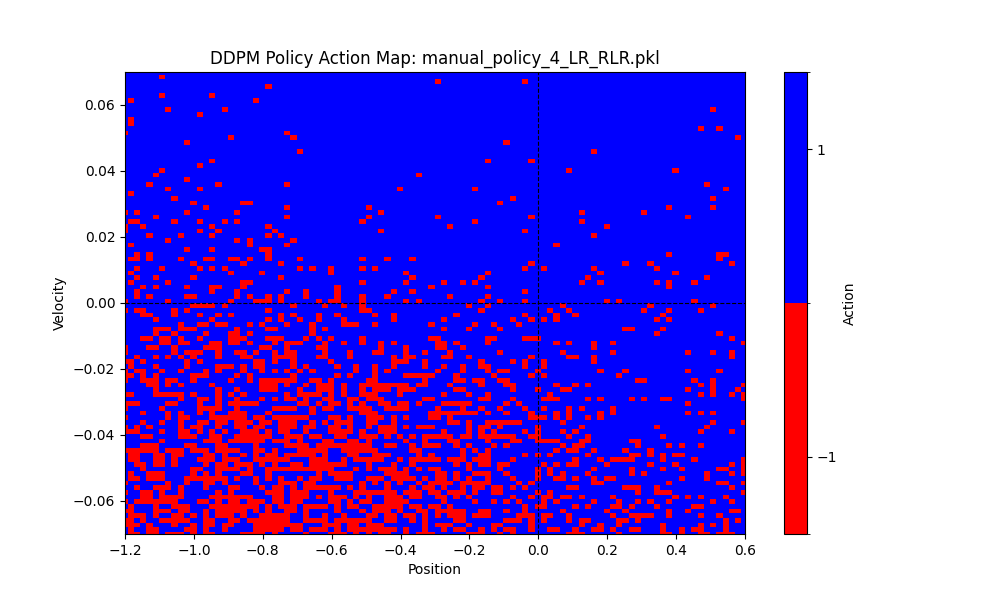

Processing manual_policy_4_RLR.pkl...


Calculating actions for manual_policy_4_RLR.pkl: 100%|██████████| 100/100 [28:00<00:00, 16.80s/it]


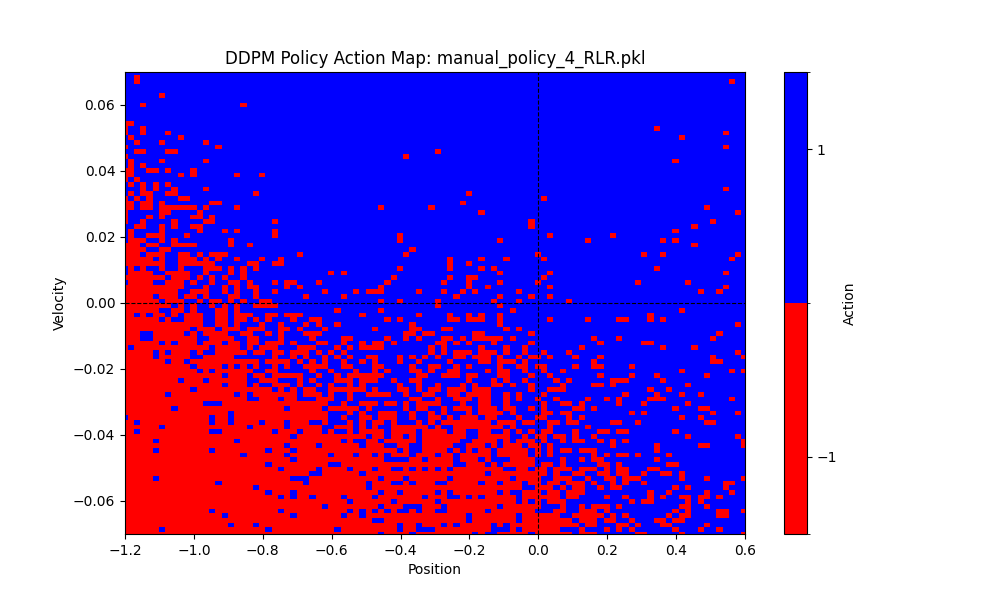

Processing manual_policy_50_LR_RLR.pkl...


Calculating actions for manual_policy_50_LR_RLR.pkl: 100%|██████████| 100/100 [27:48<00:00, 16.68s/it]


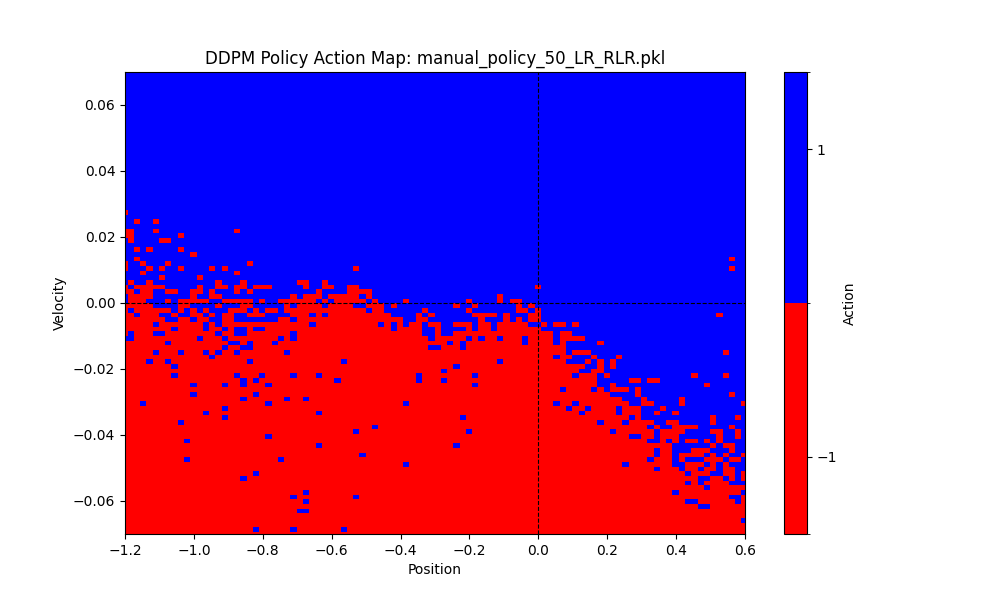

Processing manual_policy_5_LR.pkl...


Calculating actions for manual_policy_5_LR.pkl: 100%|██████████| 100/100 [27:59<00:00, 16.79s/it]


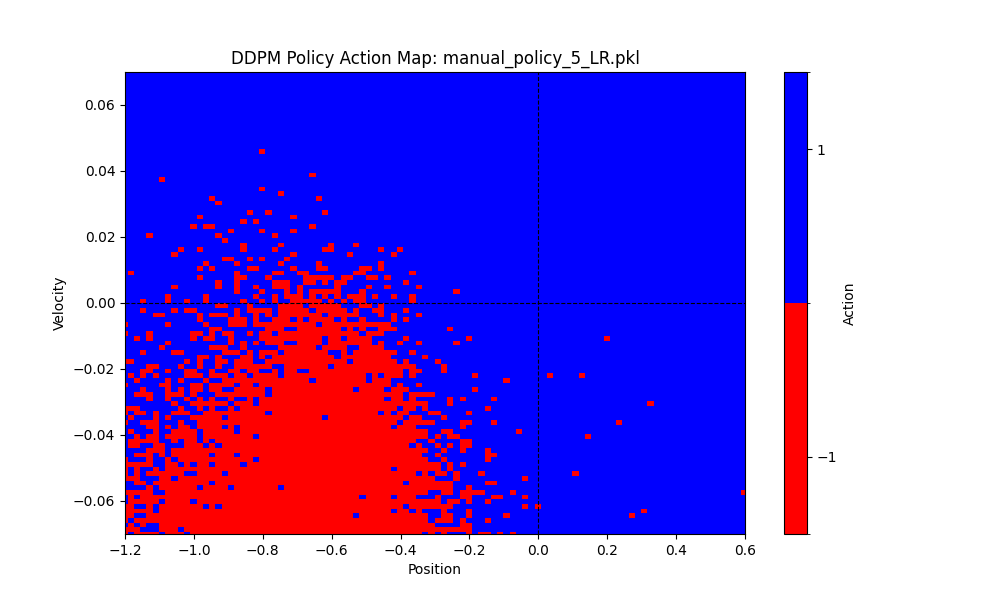

Processing manual_policy_5_LR_RLR.pkl...


Calculating actions for manual_policy_5_LR_RLR.pkl: 100%|██████████| 100/100 [27:47<00:00, 16.68s/it]


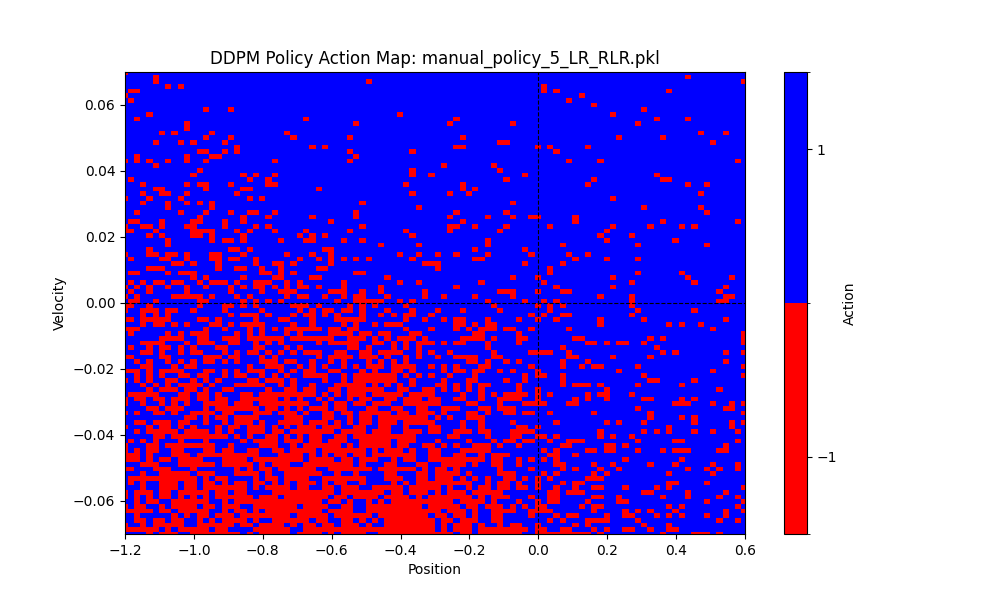

Processing manual_policy_5_RLR.pkl...


Calculating actions for manual_policy_5_RLR.pkl: 100%|██████████| 100/100 [27:56<00:00, 16.76s/it]


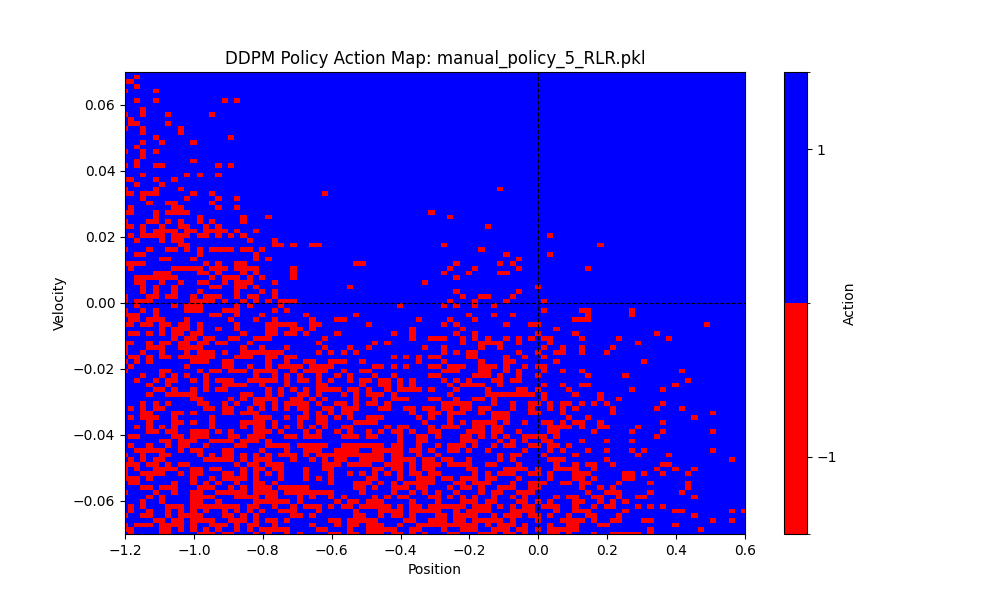

Processing manual_policy_6_LR.pkl...


Calculating actions for manual_policy_6_LR.pkl: 100%|██████████| 100/100 [27:55<00:00, 16.76s/it]


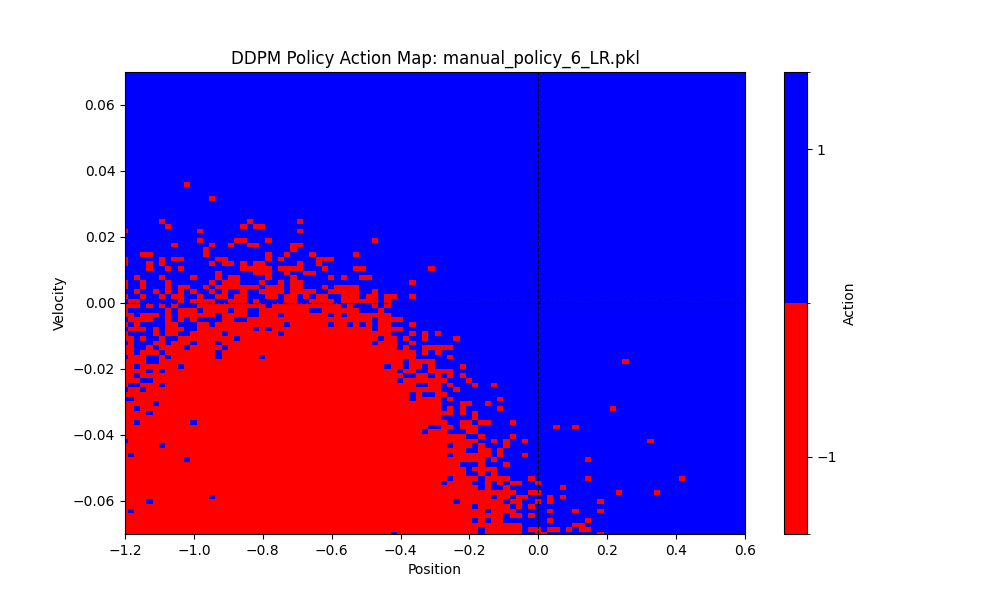

Processing manual_policy_6_LR_RLR.pkl...


Calculating actions for manual_policy_6_LR_RLR.pkl: 100%|██████████| 100/100 [27:52<00:00, 16.73s/it]


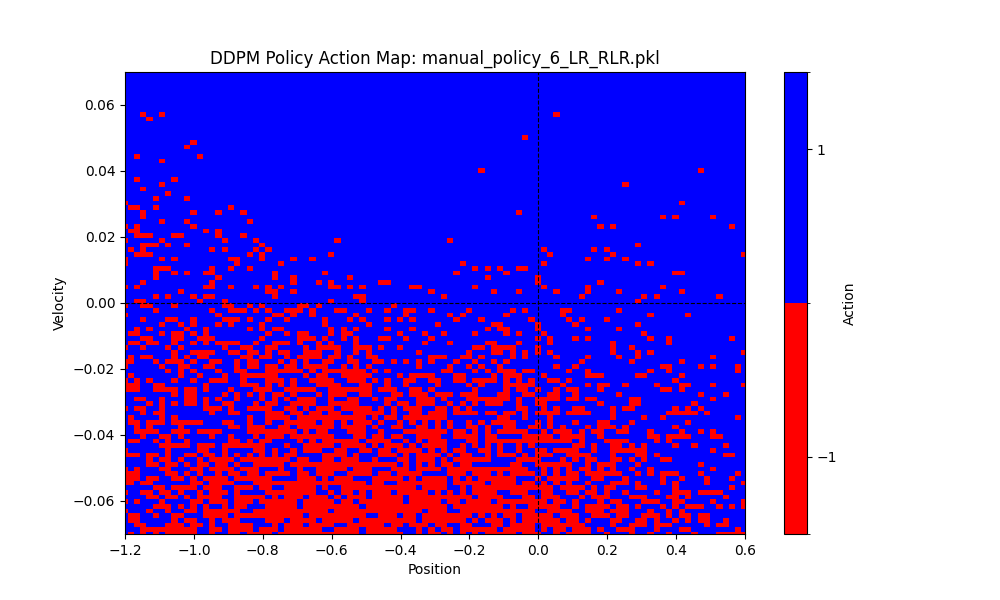

Processing manual_policy_6_RLR.pkl...


Calculating actions for manual_policy_6_RLR.pkl: 100%|██████████| 100/100 [27:52<00:00, 16.73s/it]


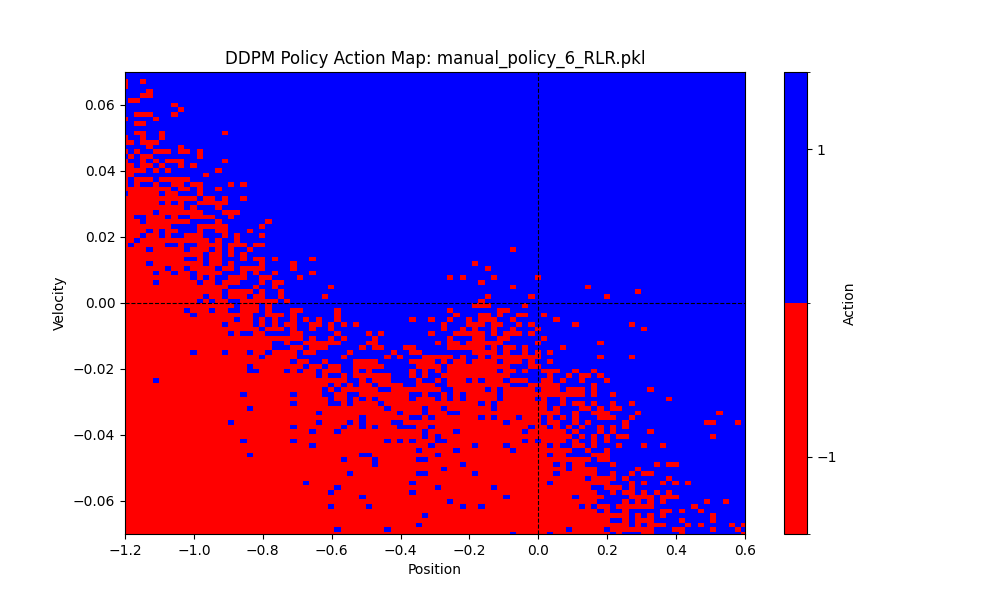

Processing manual_policy_7_LR.pkl...


Calculating actions for manual_policy_7_LR.pkl: 100%|██████████| 100/100 [27:51<00:00, 16.72s/it]


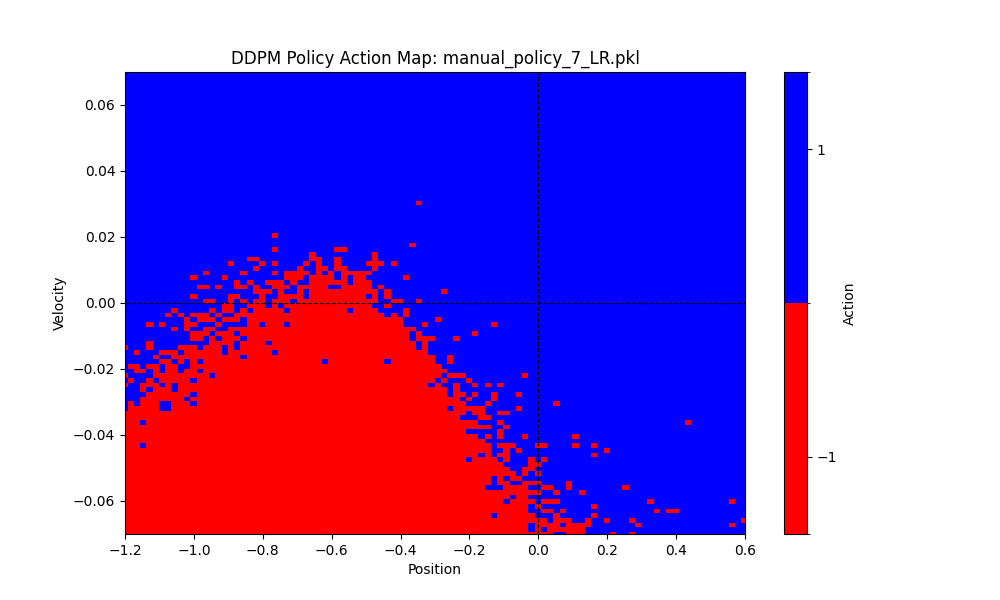

Processing manual_policy_7_LR_RLR.pkl...


Calculating actions for manual_policy_7_LR_RLR.pkl: 100%|██████████| 100/100 [27:54<00:00, 16.75s/it]


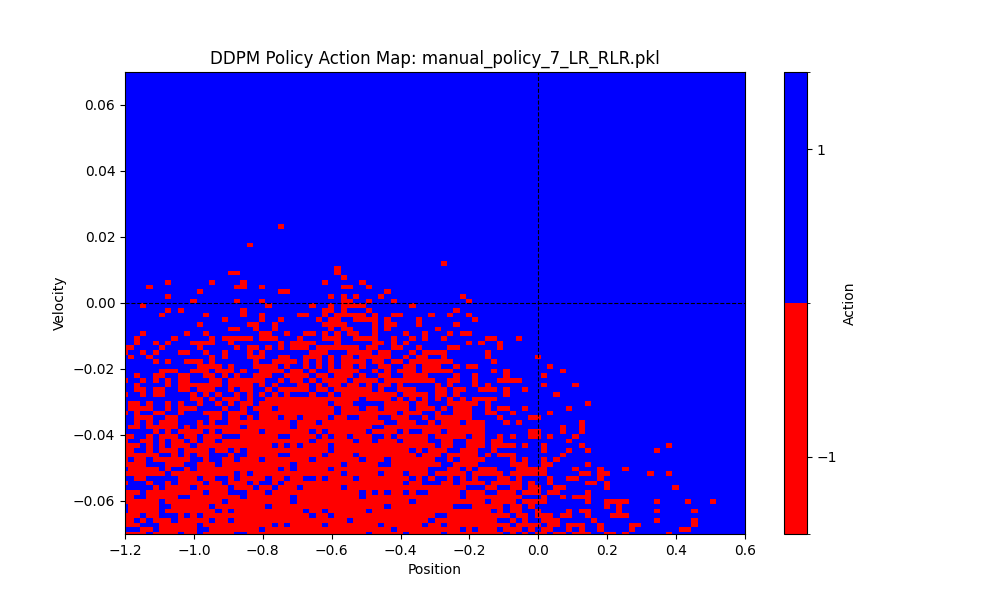

Processing manual_policy_7_RLR.pkl...


Calculating actions for manual_policy_7_RLR.pkl: 100%|██████████| 100/100 [27:54<00:00, 16.75s/it]


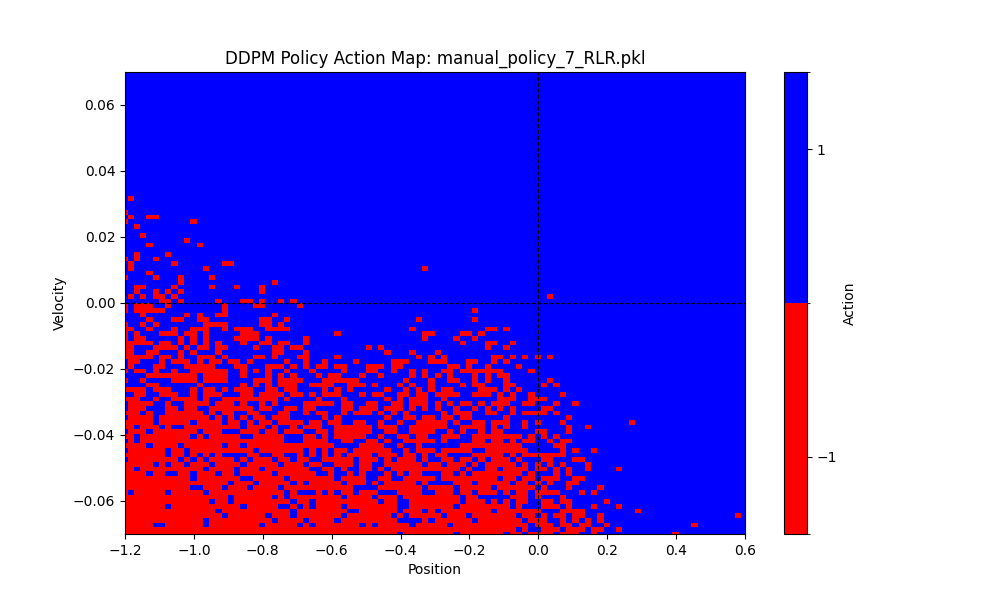

Processing manual_policy_8_LR.pkl...


Calculating actions for manual_policy_8_LR.pkl: 100%|██████████| 100/100 [27:56<00:00, 16.77s/it]


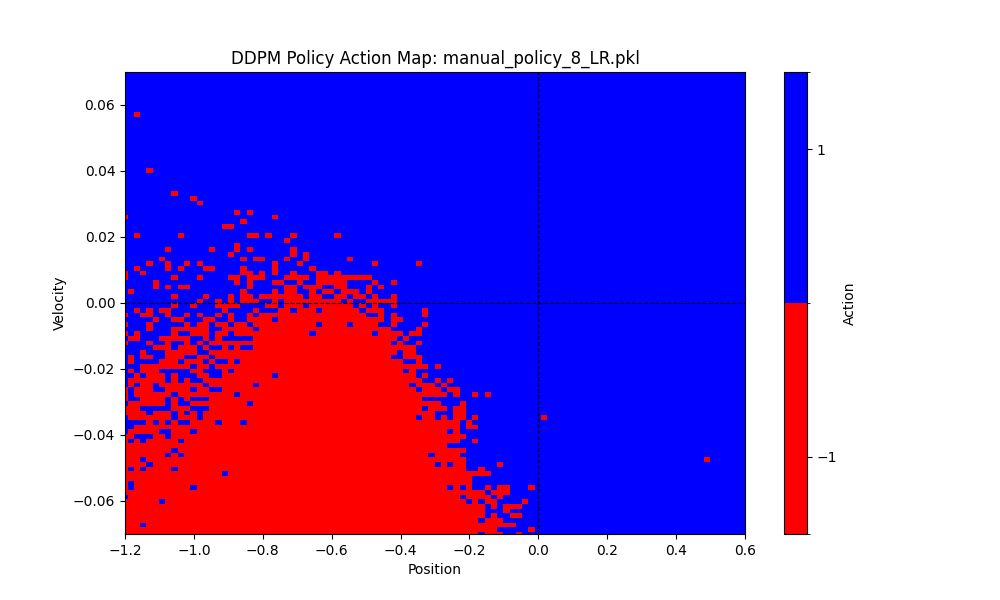

Processing manual_policy_8_LR_RLR.pkl...


Calculating actions for manual_policy_8_LR_RLR.pkl: 100%|██████████| 100/100 [28:00<00:00, 16.80s/it]


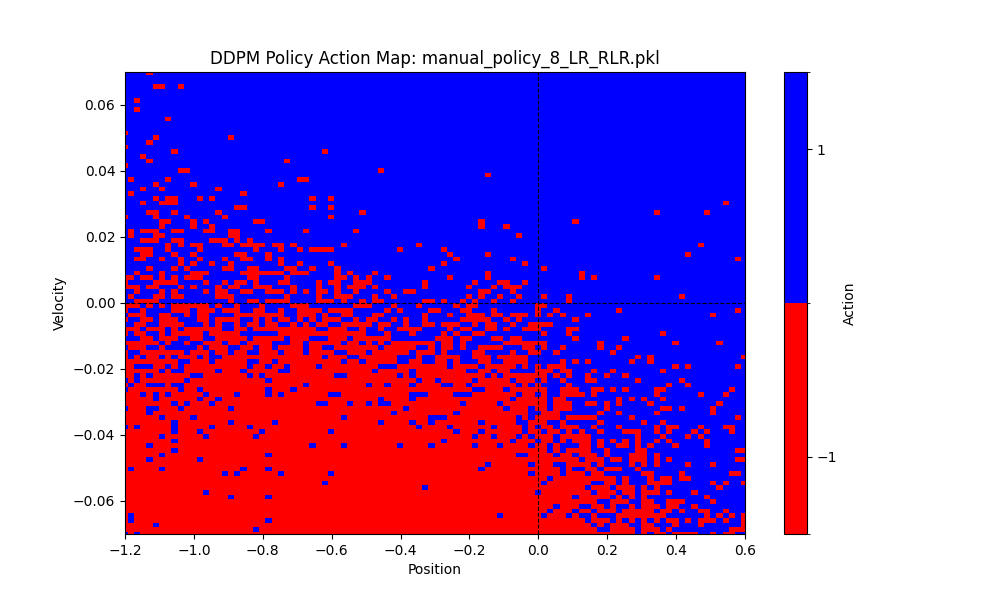

Processing manual_policy_8_RLR.pkl...


Calculating actions for manual_policy_8_RLR.pkl: 100%|██████████| 100/100 [28:11<00:00, 16.92s/it]


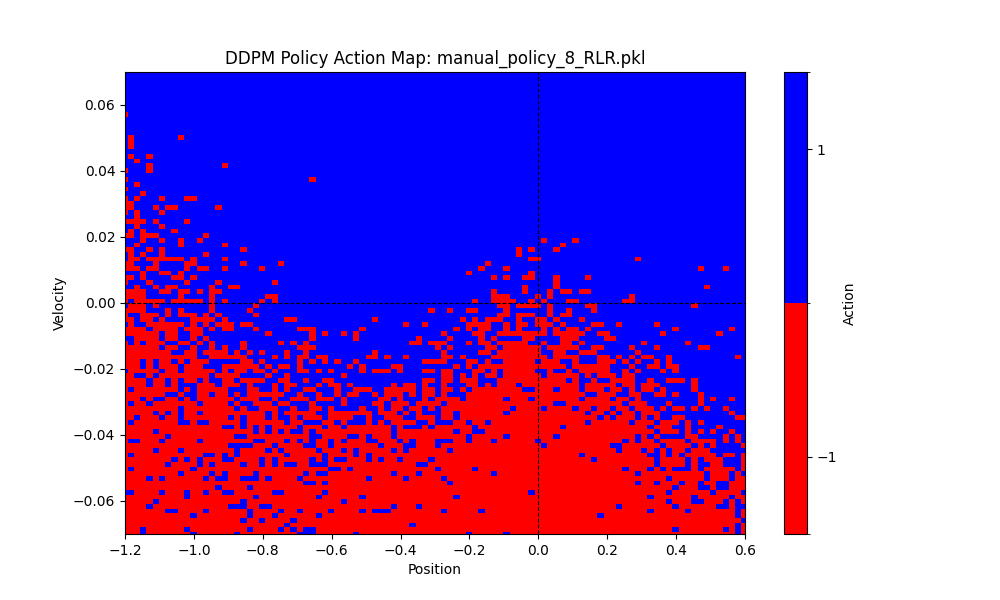

Processing manual_policy_9_LR.pkl...


Calculating actions for manual_policy_9_LR.pkl: 100%|██████████| 100/100 [28:08<00:00, 16.89s/it]


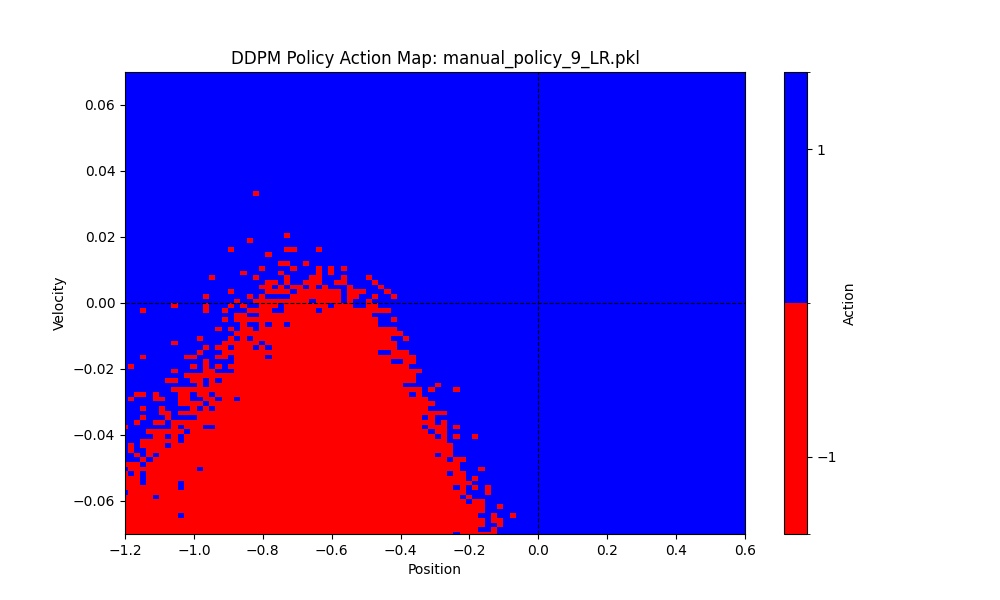

Processing manual_policy_9_LR_RLR.pkl...


Calculating actions for manual_policy_9_LR_RLR.pkl: 100%|██████████| 100/100 [28:00<00:00, 16.80s/it]


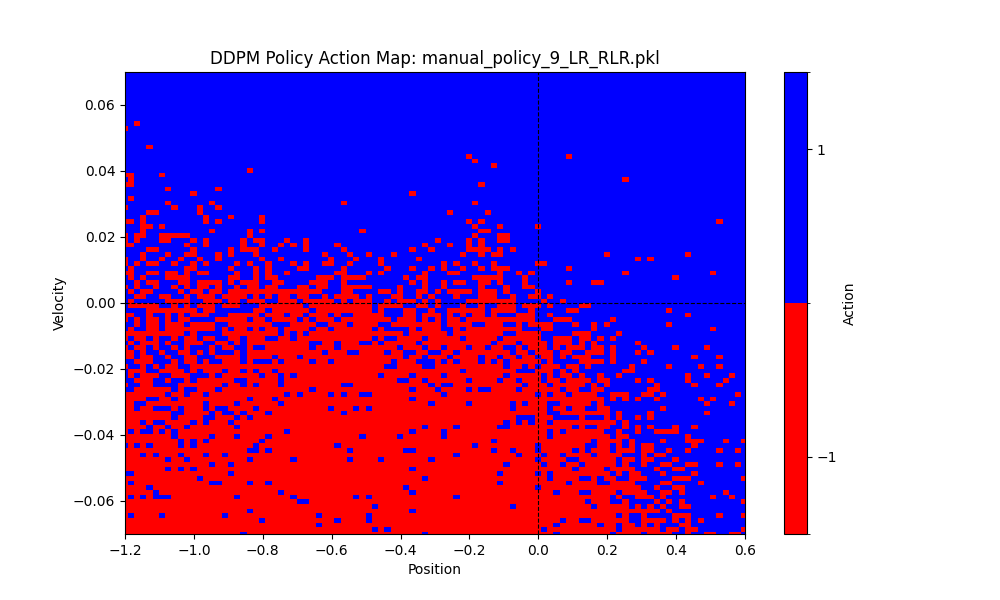

Processing manual_policy_9_RLR.pkl...


Calculating actions for manual_policy_9_RLR.pkl: 100%|██████████| 100/100 [28:01<00:00, 16.81s/it]


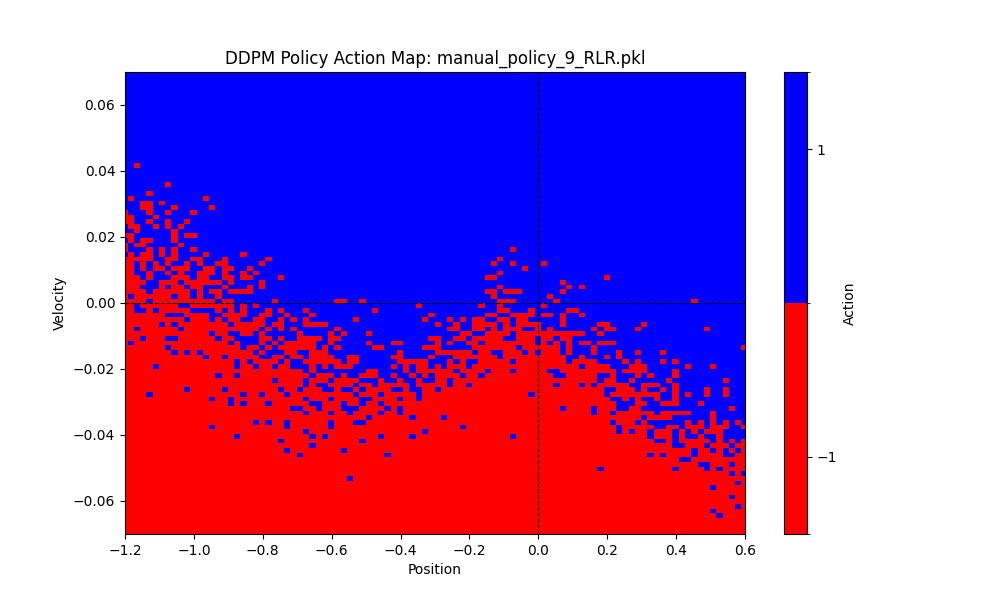

In [5]:
# 定义从DDPM模型获取动作的函数
def get_ddpm_action(observation, policy_ddpm):
    # 使用DDPM模型进行采样，确保输入为tensor格式
    action = policy_ddpm.sampling(torch.tensor(observation).float(), n=1)
    return action[0].item()  # 提取标量值

# 生成状态网格
pos_range = np.linspace(-1.2, 0.6, 100)  # Position 范围
vel_range = np.linspace(-0.07, 0.07, 100)  # Velocity 范围

# 创建网格
X, Y = np.meshgrid(pos_range, vel_range)

# 初始化黑名单
blacklist = {'learned_policy_fixed_500.pkl','learned_policy_fixed_400.pkl'}

# 遍历 ./data 目录下的所有 pkl 文件
data_dir = './data'
for file_name in os.listdir(data_dir):
    if file_name.endswith('.pkl') and file_name not in blacklist:
        file_path = os.path.join(data_dir, file_name)
        
        # 加载DDPM模型
        try:
            with open(file_path, 'rb') as f:
                policy_ddpm = pkl.load(f)
            print(f"Processing {file_name}...")
        except Exception as e:
            print(f"Error loading {file_name}: {e}")
            continue  # 如果加载失败，跳过此文件
        
        # 初始化动作存储矩阵
        actions = np.zeros(X.shape)

        # 计算每个网格点的动作
        for i in tqdm(range(X.shape[0]), desc=f"Calculating actions for {file_name}"):
            for j in range(X.shape[1]):
                state = np.array([X[i, j], Y[i, j]])
                actions[i, j] = get_ddpm_action(state, policy_ddpm)  # 使用DDPM模型获取动作

        # 使用 pcolor 绘制动作
        plt.figure(figsize=(10, 6))
        cmap = mcolors.ListedColormap(['red', 'blue'])  # 自定义颜色映射
        bounds = [-1.5, 0, 1.5]  # 动作的边界
        norm = mcolors.BoundaryNorm(bounds, cmap.N)

        # 绘制 pcolor 图
        plt.pcolor(X, Y, actions, cmap=cmap, shading='auto', norm=norm)
        plt.colorbar(ticks=[-1, 1], label='Action')
        plt.xlabel('Position')
        plt.ylabel('Velocity')
        plt.title(f'DDPM Policy Action Map: {file_name}')
        plt.axhline(0, color='black', linewidth=0.8, linestyle='--')  # 添加水平线
        plt.axvline(0, color='black', linewidth=0.8, linestyle='--')  # 添加垂直线
        plt.xlim(-1.2, 0.6)
        plt.ylim(-0.07, 0.07)
        plt.grid(False)  # 不显示网格
        plt.show()

        # 保存图像，文件名与pkl一致但扩展名为png
        img_file_path = os.path.join(data_dir, file_name.replace('.pkl', '.png'))
        plt.savefig(img_file_path)  # 保存为png图像
        plt.close()  # 关闭图像以释放内存

        # 将已处理的文件名添加到黑名单
        blacklist.add(file_name)

Processing fixed_policy_data_3.pkl...


Calculating actions for fixed_policy_data_3.pkl: 100%|██████████| 100/100 [40:17<00:00, 24.18s/it]


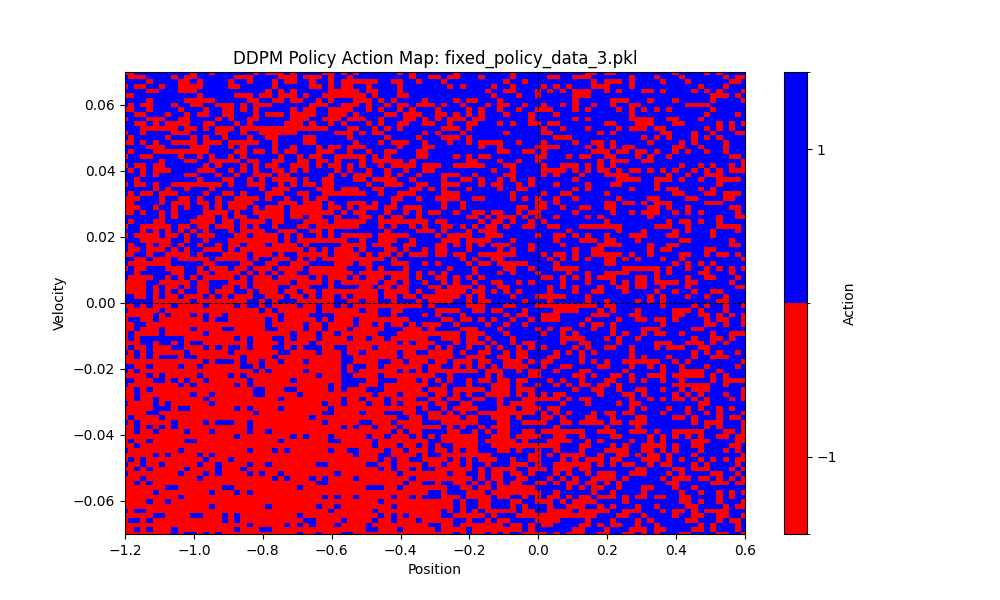

Processing fixed_policy_data_4.pkl...


Calculating actions for fixed_policy_data_4.pkl: 100%|██████████| 100/100 [39:15<00:00, 23.56s/it]


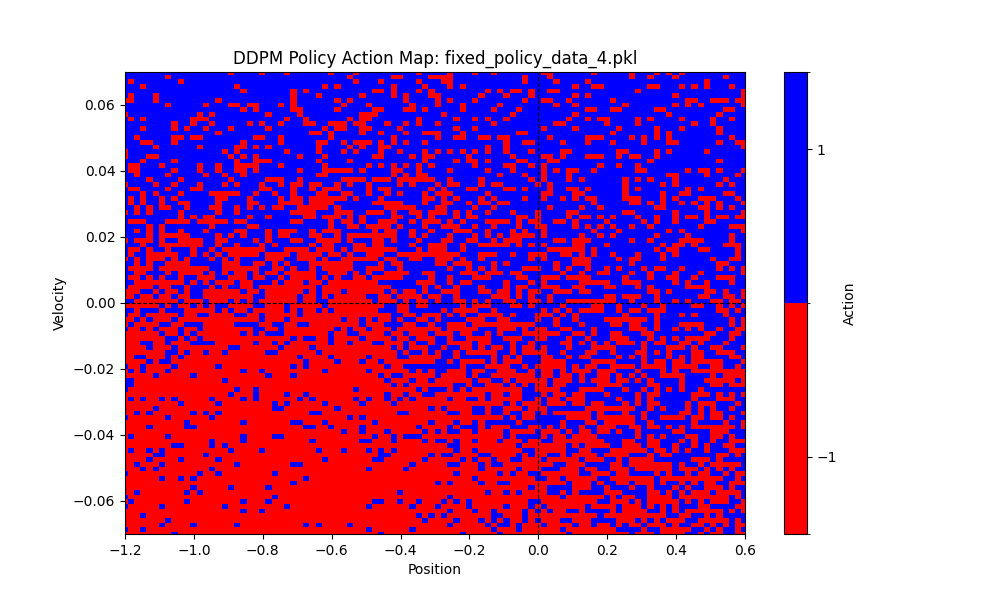

Processing fixed_policy_data_5.pkl...


Calculating actions for fixed_policy_data_5.pkl: 100%|██████████| 100/100 [40:29<00:00, 24.30s/it]


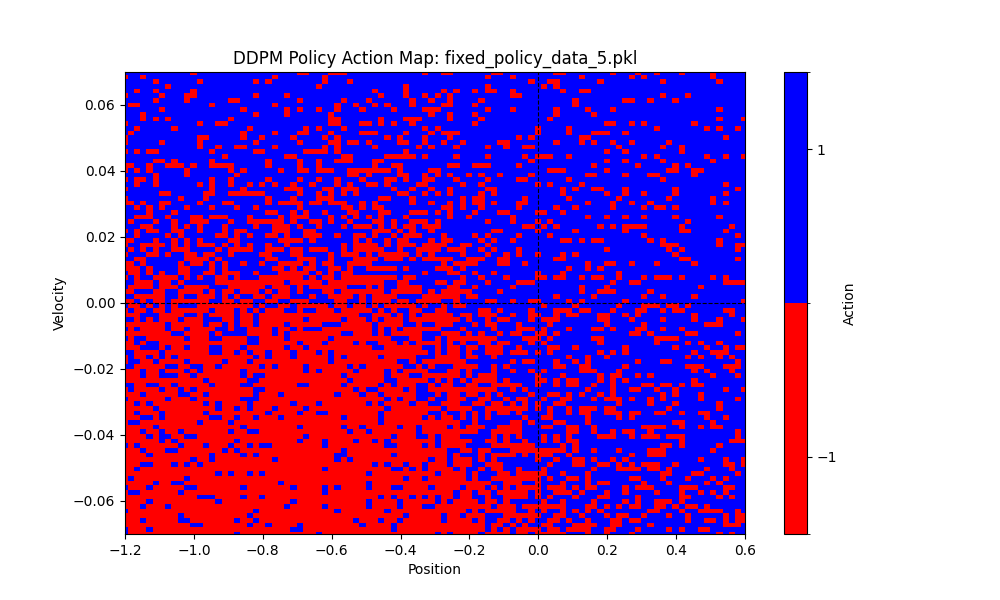

Processing fixed_policy_data_6.pkl...


Calculating actions for fixed_policy_data_6.pkl: 100%|██████████| 100/100 [40:27<00:00, 24.27s/it]


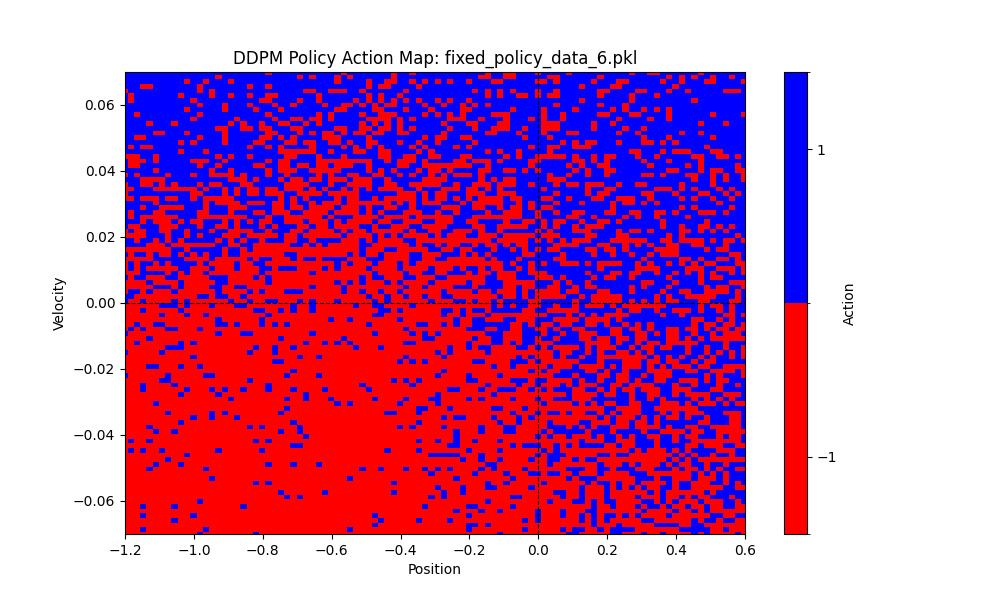

Processing fixed_policy_data_7.pkl...


Calculating actions for fixed_policy_data_7.pkl: 100%|██████████| 100/100 [39:55<00:00, 23.95s/it]


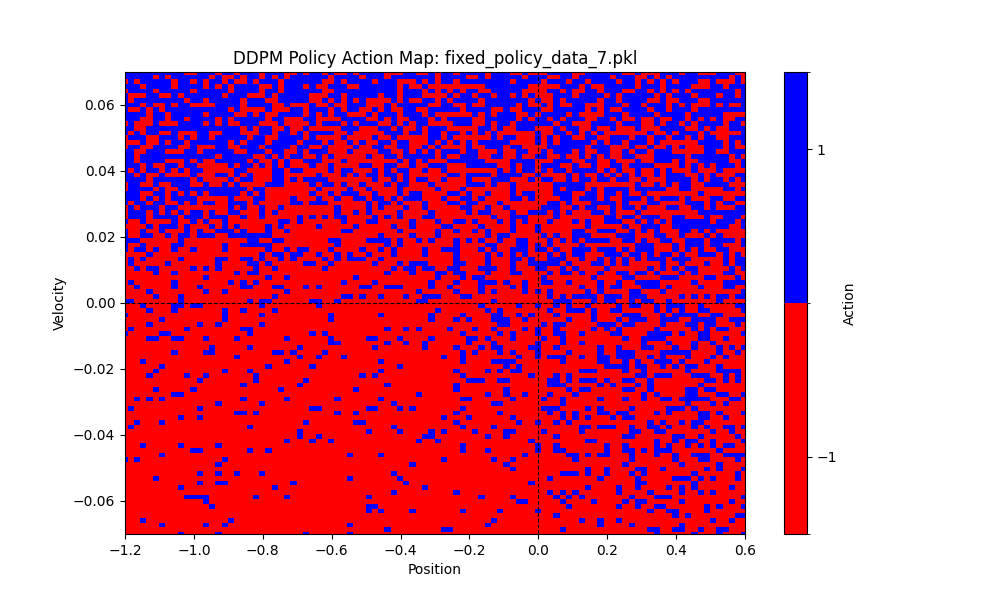

Processing fixed_policy_data_8.pkl...


Calculating actions for fixed_policy_data_8.pkl: 100%|██████████| 100/100 [49:45<00:00, 29.85s/it]


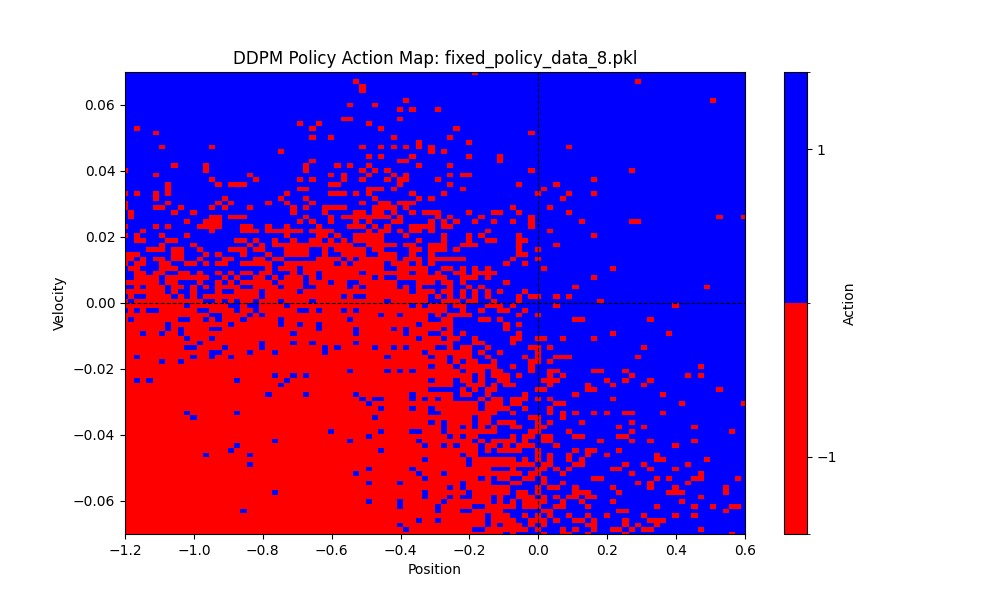

Processing fixed_policy_data_9.pkl...


Calculating actions for fixed_policy_data_9.pkl: 100%|██████████| 100/100 [40:48<00:00, 24.48s/it]


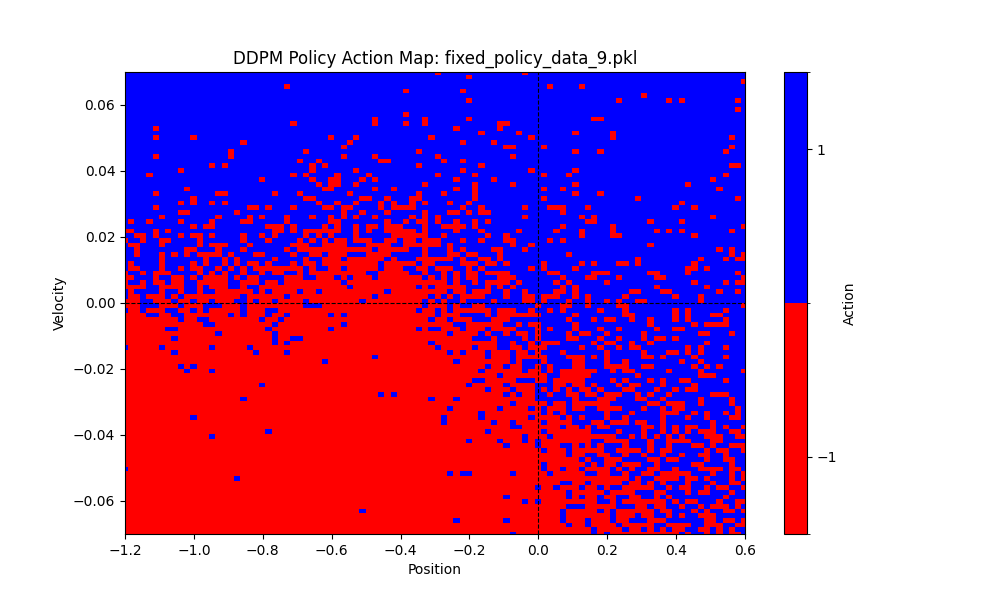

No such comm: a3610de5f7d74c779194c928c56bf41b
No such comm: a3610de5f7d74c779194c928c56bf41b


In [5]:
# 定义从DDPM模型获取动作的函数
def get_ddpm_action(observation, policy_ddpm):
    # 使用DDPM模型进行采样，确保输入为tensor格式
    action = policy_ddpm.sampling(torch.tensor(observation).float(), n=1)
    return action[0].item()  # 提取标量值

# 生成状态网格
pos_range = np.linspace(-1.2, 0.6, 100)  # Position 范围
vel_range = np.linspace(-0.07, 0.07, 100)  # Velocity 范围

# 创建网格
X, Y = np.meshgrid(pos_range, vel_range)

# 初始化黑名单
blacklist = {'learned_policy_fixed_500.pkl','learned_policy_fixed_400.pkl'}

# 遍历 ./data 目录下的所有 pkl 文件
data_dir = './data2'
for file_name in os.listdir(data_dir):
    if file_name.endswith('.pkl') and file_name not in blacklist:
        file_path = os.path.join(data_dir, file_name)
        
        # 加载DDPM模型
        try:
            with open(file_path, 'rb') as f:
                policy_ddpm = pkl.load(f)
            print(f"Processing {file_name}...")
        except Exception as e:
            print(f"Error loading {file_name}: {e}")
            continue  # 如果加载失败，跳过此文件
        
        # 初始化动作存储矩阵
        actions = np.zeros(X.shape)

        # 计算每个网格点的动作
        for i in tqdm(range(X.shape[0]), desc=f"Calculating actions for {file_name}"):
            for j in range(X.shape[1]):
                state = np.array([X[i, j], Y[i, j]])
                actions[i, j] = get_ddpm_action(state, policy_ddpm)  # 使用DDPM模型获取动作

        # 使用 pcolor 绘制动作
        plt.figure(figsize=(10, 6))
        cmap = mcolors.ListedColormap(['red', 'blue'])  # 自定义颜色映射
        bounds = [-1.5, 0, 1.5]  # 动作的边界
        norm = mcolors.BoundaryNorm(bounds, cmap.N)

        # 绘制 pcolor 图
        plt.pcolor(X, Y, actions, cmap=cmap, shading='auto', norm=norm)
        plt.colorbar(ticks=[-1, 1], label='Action')
        plt.xlabel('Position')
        plt.ylabel('Velocity')
        plt.title(f'DDPM Policy Action Map: {file_name}')
        plt.axhline(0, color='black', linewidth=0.8, linestyle='--')  # 添加水平线
        plt.axvline(0, color='black', linewidth=0.8, linestyle='--')  # 添加垂直线
        plt.xlim(-1.2, 0.6)
        plt.ylim(-0.07, 0.07)
        plt.grid(False)  # 不显示网格
        plt.show()

        # 保存图像，文件名与pkl一致但扩展名为png
        img_file_path = os.path.join(data_dir, file_name.replace('.pkl', '.png'))
        plt.savefig(img_file_path)  # 保存为png图像
        plt.close()  # 关闭图像以释放内存

        # 将已处理的文件名添加到黑名单
        blacklist.add(file_name)